In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Question 1**

In [ ]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


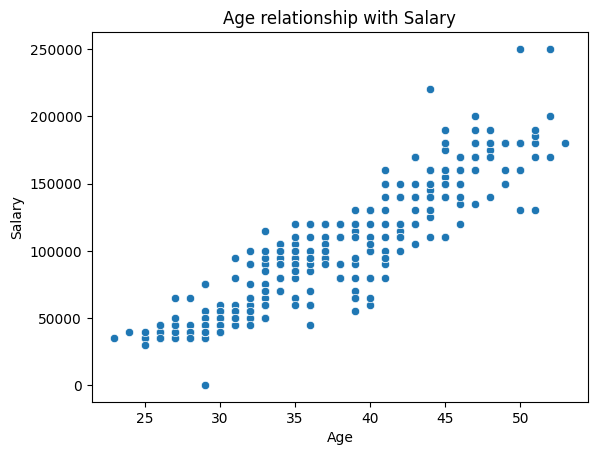

In [ ]:
# Visualize the relationship between Age and Salary

sns.scatterplot(x=df['Age'], y=df['Salary'])
plt.title("Age relationship with Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

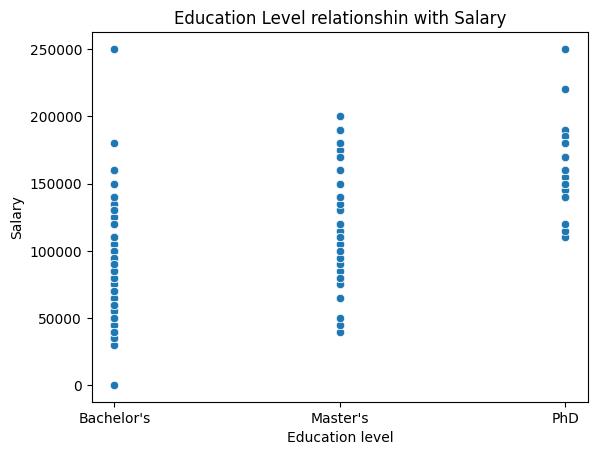

In [ ]:
sns.scatterplot(x=df['Education Level'], y=df['Salary'])
plt.title("Education Level relationshin with Salary")
plt.xlabel("Education level")
plt.ylabel("Salary")
plt.show()

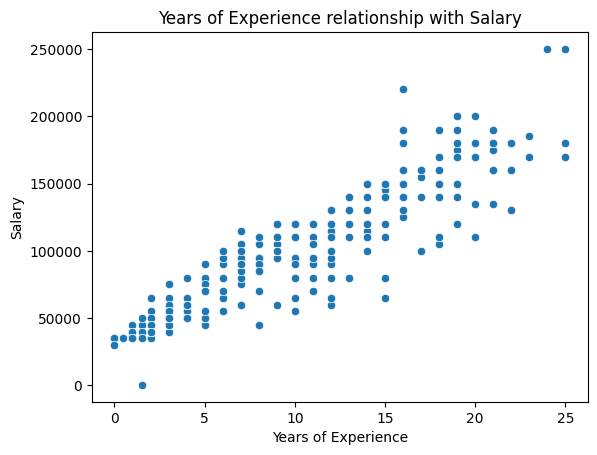

In [ ]:
sns.scatterplot(
    x=df['Years of Experience'], y=df['Salary']
)
plt.title("Years of Experience relationship with Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

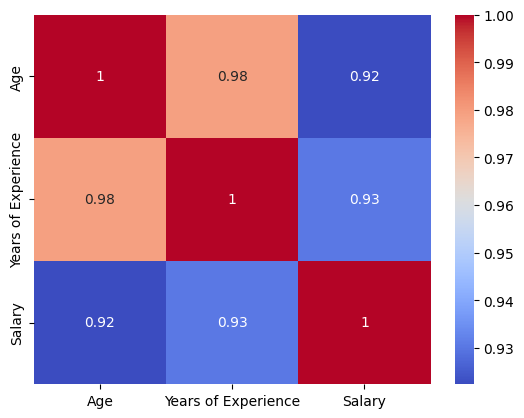

In [ ]:
from IPython.core.compilerop import CachingCompiler
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap="coolwarm"
)

plt.show()

**Question 2:**

In [ ]:
X = np.array([
    # features : study_hours, sleep_hours, attendance_pct
    [2, 6, 70],
    [3, 7, 75],
    [4, 6, 80],
    [5, 8, 85],
    [6, 7, 90],
    [7, 8, 92],
    [8, 7, 95],
    [4, 5, 78],
    [9, 8, 98],
    [10, 7, 100]
])

# Target: exam_score
y = np.array([
    45,
    50,
    58,
    65,
    72,
    80,
    85,
    55,
    92,
    96
])

In [ ]:
def make_prediction(X, W, b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = np.dot(W, X[i]) + b

  return pred_list

In [ ]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

# predictions
y_pred = make_prediction(X, W_init, b_init)
print(y_pred)

print("\nActual vs Predicted")

for actual, pred in zip(y, y_pred):
  print(f"Actual: {actual:3d} | Predicted: {pred:.2f}")

[ 79.  86.  91.  99. 104. 108. 111.  88. 116. 118.]

Actual vs Predicted
Actual:  45 | Predicted: 79.00
Actual:  50 | Predicted: 86.00
Actual:  58 | Predicted: 91.00
Actual:  65 | Predicted: 99.00
Actual:  72 | Predicted: 104.00
Actual:  80 | Predicted: 108.00
Actual:  85 | Predicted: 111.00
Actual:  55 | Predicted: 88.00
Actual:  92 | Predicted: 116.00
Actual:  96 | Predicted: 118.00


**Question 3:**

In [ ]:
from sklearn.datasets import fetch_california_housing


In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns= housing.feature_names
)

df['target'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [ ]:
# MedInc, AveRooms, HouseAge — শুধু এই ৩টি feature নাও

X = df[['MedInc', 'HouseAge', 'AveRooms']]
y = df['target']

In [ ]:
# model train
model = LinearRegression()

model.fit(X, y)

# Coefficients & Intercept
print("Coefficients : ", model.coef_)
print("Intercept : ", model.intercept_)

Coefficients :  [ 0.4427634   0.01682208 -0.02715343]
Intercept :  0.02040695696458039


In [ ]:
# predict
y_pred = model.predict(X)

print("\nActual vs Predicted")
print("-"*30)

for actual, pred in zip(y[:5], y_pred[:5]):
  print(f"Actual: {actual:.3f} | Predicted: {pred:.3f}")


Actual vs Predicted
------------------------------
Actual: 4.526 | Predicted: 4.207
Actual: 3.585 | Predicted: 3.880
Actual: 3.521 | Predicted: 3.883
Actual: 3.413 | Predicted: 3.236
Actual: 3.422 | Predicted: 2.428


**Q4. MSE Cost Function implement ও visualize করো Q2 এর data ব্যবহার করো।**

In [ ]:
X = np.array([
    # features : study_hours, sleep_hours, attendance_pct
    [2, 6, 70],
    [3, 7, 75],
    [4, 6, 80],
    [5, 8, 85],
    [6, 7, 90],
    [7, 8, 92],
    [8, 7, 95],
    [4, 5, 78],
    [9, 8, 98],
    [10, 7, 100]
])

# Target: exam_score
y = np.array([
    45,
    50,
    58,
    65,
    72,
    80,
    85,
    55,
    92,
    96
])

In [ ]:
def predict(X, W, b):
  return np.dot(X, W) + b

def compute_cost(X, y, w, b):
  m = X.shape[0]

  y_pred = predict(X, w, b)
  cost = np.sum((y_pred - y) ** 2) / (2 * m)
  return cost

In [ ]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X,y, W_init ,b_init)

np.float64(466.5)

In [ ]:
w_fixed = np.array([1.0, 2.0, 0.5])
b = 5.0

w0_values = np.linspace(-10, 10, 100)
costs = []

for w0 in w0_values:
  w = w_fixed.copy()
  w[0] = w0

  cost = compute_cost(X, y, w, b)
  costs.append(cost)

In [ ]:
min_idx = np.argmin(costs)

best_w0 = w0_values[min_idx]
min_cost = costs[min_idx]

print("Best w[0] =", best_w0)
print("Minimum Cost =", min_cost)

Best w[0] = 1.9191919191919187
Minimum Cost = 26.40900800938679


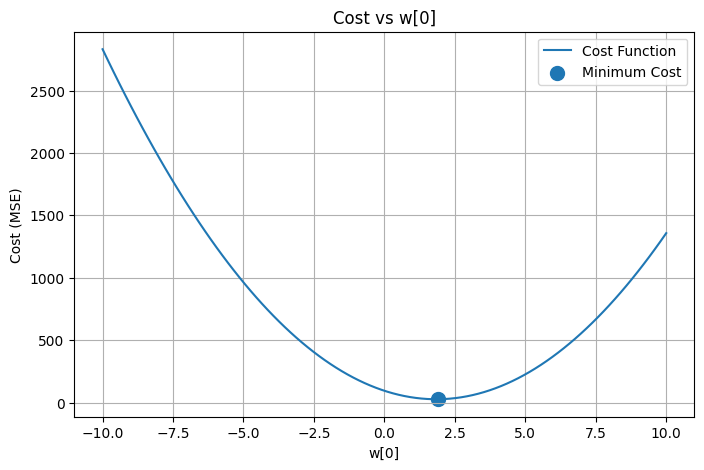

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(w0_values, costs, label="Cost Function")

plt.scatter(
    best_w0,
    min_cost,
    s=100,
    marker="o",
    label="Minimum Cost"
)

plt.xlabel("w[0]")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs w[0]")
plt.legend()
plt.grid(True)

plt.show()

**Q5. Gradient Descent from Scratch Advertising dataset (TV, Radio, Newspaper → Sales)।**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv")

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

In [ ]:
from os import error
# Prediction Function
def predict(X, w, b):
  return X @ w + b


In [ ]:
  # Cost Function

def compute_cost(X, y, w, b):
    m = X.shape[0]

    y_pred = predict(X, w, b)

    cost = np.sum((y_pred - y) ** 2) / (2 * m)

    return cost

In [ ]:
# Gradient Formula

def compute_gradient(X, y, w, b):
    m = X.shape[0]

    y_pred = predict(X, w, b)
    error = y_pred - y
    dw = (1 / m) * (X.T @ error)
    db = (1 / m) * np.sum(error)

    return dw, db

In [ ]:
# Gradient Descent

def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input.copy()
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = compute_gradient(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"Iteration {i}: Cost: {cost:0.4f}, dj_dw: {dj_dw}, dj_db: {dj_db}, w: {w}, b: {b}")

  return w, b, cost_memo, iteration

In [ ]:
w_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = w_init, b_input = b_init, max_iter = 1000, alpha = 0.0001)

Iteration 0: Cost: 422.6053, dj_dw: TV          -2410.54170
radio        -370.63195
newspaper    -454.25515
dtype: float64, dj_db: -14.0225, w: TV           0.241054
radio        0.037063
newspaper    0.045426
dtype: float64, b: 0.00140225
Iteration 100: Cost: 2659999926608622803130148496754998014863506802627922310123749376.0000, dj_dw: TV          -6.159476e+33
radio       -7.600812e+32
newspaper   -1.007524e+33
dtype: float64, dj_db: -3.165987515932551e+31, w: TV           4.115798e+29
radio        5.078908e+28
newspaper    6.732333e+28
dtype: float64, b: 2.1155318328727357e+27
Iteration 200: Cost: 17109903353528665965547786625850116435973592687552242922417007458418273573423032258046486898519322014569160921574316110249984.0000, dj_dw: TV          -1.562164e+64
radio       -1.927715e+63
newspaper   -2.555278e+63
dtype: float64, dj_db: -8.029567695702738e+61, w: TV           1.043848e+60
radio        1.288111e+59
newspaper    1.707452e+59
dtype: float64, b: 5.365405257911196e+57
Iterat

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Iteration 900: Cost: inf, dj_dw: TV          -1.054405e+277
radio       -1.301139e+276
newspaper   -1.724721e+276
dtype: float64, dj_db: -5.419671018383047e+274, w: TV           7.045597e+272
radio        8.694289e+271
newspaper    1.152469e+272
dtype: float64, b: 3.621456656221192e+270
